# Create a realistic ECG plot

## Import library 

In [89]:
# import library

import numpy as np
import matplotlib.pyplot as plt


## Load data 

ECG raw data are in ECGu.text file, we need to load the data so that we can use them in this Jupyter Notebbok. To check that it works, writing the name of variable (ECG_raw) enable us to see a summary of the data.

In [90]:
# load the data file from the data file ECGu.txt

ECG_raw = np.loadtxt('ECGu.txt')
ECG_raw

# for shape (x,y), x=number of lines, y=number of columns

array([[-275., -119., -119.],
       [-275., -119., -119.],
       [-275., -118., -121.],
       ...,
       [  -4.,  -83.,   21.],
       [  -9.,  -88.,   31.],
       [ -16.,  -96.,   33.]], shape=(6500, 3))

## Plot the raw ECG data

The ECG raw data can now be used to create a plot. This command (plot a signal) will be used later to create the real ECG plot, so a function is created to avoid repeating the same piece of code. Parameters (in orange) enable us to change the variables and name of elements on the graph depending on the plot (ECG raw Signal or later ECG Signal). The parameter time is used but is asked not to be taking into account for the ECG raw Signal because for the moment only the variable ECG_raw is needed. It is nevertheless used as later time will be used because the data of ECG raw will be converted in real ECG values. 

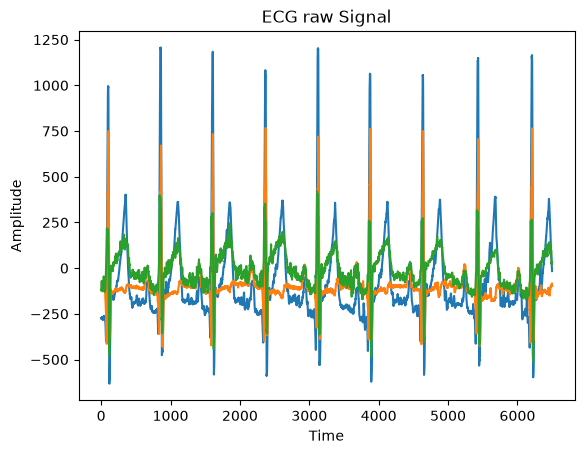

In [91]:
# plot the ECG signal

# simplified version of the code to plot the ECG signal, create a general function to plot the ECG signal
def plot_ecg_signal(ecg_data, title, x_label, y_label, time=None):
    if time is None: # condition
        plt.plot(ecg_data)
    else:
        plt.plot(time, ecg_data)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()

plot_ecg_signal(ECG_raw, 'ECG raw Signal', 'Time', 'Amplitude')

### Description of the plot 

The graph looks okay. The units are missing from the axes, but they are not known yet. 

The values look like raw data, because the actual values of an ECG signal are typicallly in the order of 0.5 milivolts, as explained on this page : https://fr.my-ekg.com/generalites-ecg/papier-ecg.html

The waveform looks like an ECG waveform, as shown on this page :  http://www.ecglibrary.com/norm.php

## Rescale ECG data

In order to convert the data, the following information are needed : 

The ECG recording equipment manufacturer's instructions specify:

Leads recorded  : I, II, III
Sampling frequency : 1000 Hz 
A/D converter gain : 1024 µV per unit  

For each axis, the data will be converted.
For y axis, ECG_raw will be converted in real ECG values by being divided by 1 024. Not sure about the formula because if the raw data is multiply by 1 024, the results are too big for ECG values.
For x axis, the variable time did not really exist in the ECGu.text file so it is created to get the time in seconds. To do so, the lenght of ECG_raw is devided by the sampling frequency. 


In [92]:
# Convert the ECG raw data to real values

# Convert y axis 
ECG_real = ECG_raw / 1024 # 1 raw unit = 1 024 µV = 1.024 mV ?

#Convert x axis
sampling_frequency = 1000
timestamps = np.arange(len(ECG_raw)) / sampling_frequency # np.arange() creates an array of evenly spaced values within a given interval, len(ECG_raw) gives the number of samples in the ECG_raw array, and dividing by the sampling frequency converts the sample indices to time in seconds.

## Plot ECG signal

Now that the values are converted, the real ECG Signal can be plot. Because the function alraedy exists, it is only needed to change the variables and the titles of the elements on the graph. 

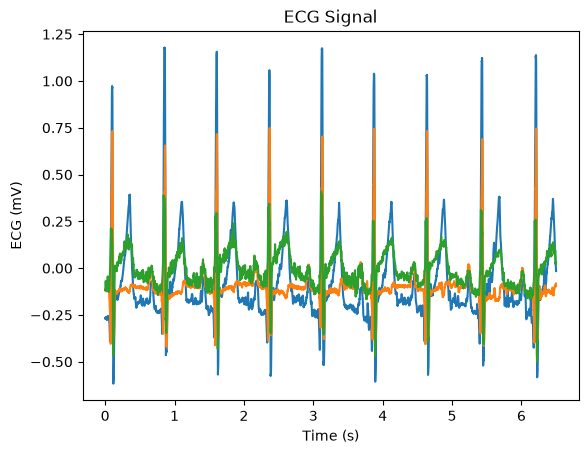

In [93]:
# plot the real ECG signal

# use function to plot the real ECG signal
plot_ecg_signal(ECG_real, 'ECG Signal', 'Time (s)', 'ECG (mV)', timestamps)

### Check the plot 

The number of timeseries and samples are correct. 
The values are consistent with the range of ECG signals  https://fr.my-ekg.com/generalites-ecg/papier-ecg.html.
The waveform is also coherent.
The signal starts at 0s and ends at 6.5 which is coherent with the number of lines and the sampling frequency. 



## Plot a realistic ECG plot


### Add grid 

By using fonctions, create the grid. 
First fonction (plot_grid) is used to plot a general grid, with all the parameters. It indicates the parameters for each axis. 
The second function (plot_ecg_grid) is used to add the values for the transparency (alpha), the color and the values for the lines intervals. It also enables us to create thick lines and thin lines. 
At the end of this cell, fonctions are used to directly use the max and min values. 

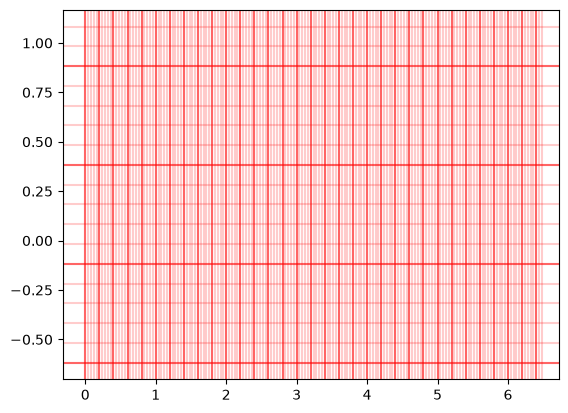

In [94]:
# Create a grid 
def plot_grid(seconds_per_square, mV_per_square, alpha,
              min_time, max_time, min_ecg, max_ecg, color): # parameters for the grid, alpha is the transparency of the grid lines

    # vertical lines
    for time in np.arange(min_time, max_time, seconds_per_square): # loop : for each value (start, end, step), time is a new variable 
        plt.axvline(time, alpha=alpha, color=color) # on x axis

    # horizontal lines
    for ecg in np.arange(min_ecg, max_ecg, mV_per_square):
        plt.axhline(ecg, alpha=alpha, color=color) # on y axis
        
def plot_ecg_grid(min_time, max_time, min_ecg, max_ecg):
# thick grid lines
    plot_grid(0.2, 0.5, 0.5, # (seconds_per_square, mV_per_square, alpha) 0.2s (vertical) 0.5 mV (horizontal) (standard ECG grid,) 0.5 is the transparency of the grid lines
              min_time, max_time, min_ecg, max_ecg, 'red')
# thin grid lines
    plot_grid(0.04, 0.1, 0.2, # (seconds_per_square, mV_per_square, alpha) divided by 5 for the two first values, more transparent grid lines
              min_time, max_time, min_ecg, max_ecg, 'red')
    
plot_ecg_grid( # parameters for the grid (fonctions) 
    timestamps.min(), # directly use the min and max values of the timestamps and ECG_real arrays to set the limits of the grid
    timestamps.max(),
    ECG_real.min(),
    ECG_real.max()
)

plt.show()

### Plot the ECG signal of one lead on the grid

Create a new fonction (plot_one_ecg_signal) to plot one lead on the grid. 
Add the grid with the fonction (plot_ecg_grid). 


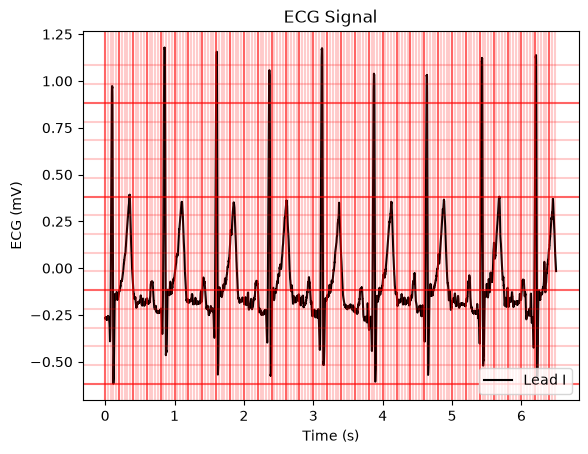

In [95]:
def plot_one_ecg_signal(time, ecg, lead_name, color):

    plt.plot(time, ecg, color=color, label=lead_name)

    plot_ecg_grid(# add the grid to the plot, values are around the lead I values, so the grid is centered around the signal
        time.min(),
        time.max(),
        ecg.min(),
        ecg.max()
    )

    plt.xlabel('Time (s)')
    plt.ylabel('ECG (mV)')
    plt.title('ECG Signal')
    plt.legend()# will automatically create a legend based on the label parameter 
    
plot_one_ecg_signal(
    timestamps,
    ECG_real[:, 0],# take all the lines of the first column (so Lead I), 0 is the index of the first column, 1 for Lead II, 2 for Lead III
    'Lead I',
    'black'
)
    

### Plot Lead I in Subplot

Create a new fonction to make Lead I a subplot. 
plt.subplot is needed to make the structure of the big plot by separating the subplots. 
We call the fonction plot_one_ecg_signal, to apply the fonction the new fonction to lead I.


In [96]:
def plot_one_lead_in_subplots(subplot, time, ecg, lead_name, color):

    plt.subplot(3, 1, subplot)# 3 : lines, 1 : columns, subplot : position of the subplot

    plot_one_ecg_signal(time, ecg, lead_name, color)# fonction already created for one ecg signal


### Plot the 3 leads

Create a new fonction for plot every subplots. Use a loop to do the same thing for each lead. i keeps track of which lead we are currently processing (variable that counts). 

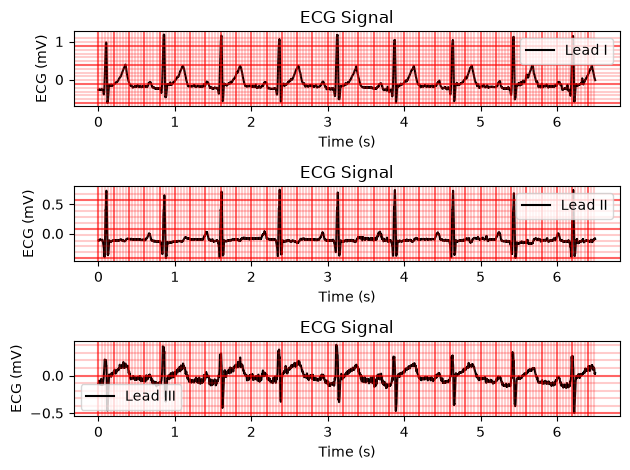

In [97]:
# New fonction to plot all leads in subplots
def plot_all_leads_in_subplots(time, ecg, lead_names, colors):

    for i in range(3):# loop for each lead (Lead I, Lead II, Lead III)

        plot_one_lead_in_subplots(# i is for each lead 
            i + 1,
            time,
            ecg[:, i],
            lead_names[i],
            colors[i]
        )

    plt.tight_layout()# to put one lead on top of the other, without overlapping the titles and labels of the axes


# Titles and colors of the leads
lead_names = ['Lead I', 'Lead II', 'Lead III']
colors = ['black', 'black', 'black']


# Plot all three leads in subplots
plot_all_leads_in_subplots(
    timestamps,
    ECG_real,
    lead_names,
    colors
)

plt.show()

### Make it more realistic

Call the fonctions plot_all_leads_in_subplots.
Use a loop to remove the title axis, ticks, title of the graph to make it more realistic. 
Add the title for each lead. 

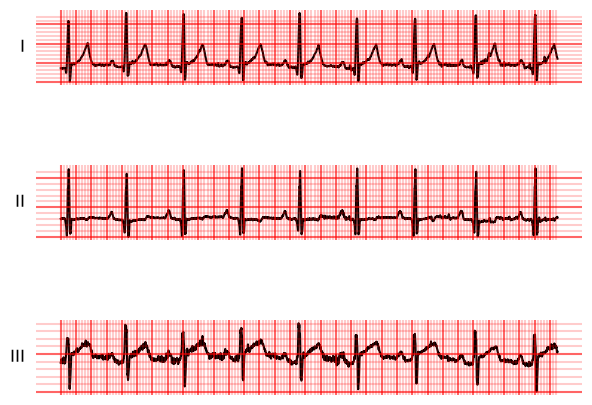

In [98]:
plot_all_leads_in_subplots(
    timestamps,
    ECG_real,
    lead_names,
    colors
)

# Remove labels, titles, axes and legend
for ax, lead in zip(plt.gcf().axes, ['I', 'II', 'III']):# zip assigns each axis to a lead
    ax.set_xlabel('')
    ax.set_title('')
    ax.legend().remove()
    ax.set_axis_off()

    # Ajouter I, II, III à gauche
    ax.text(-0.02, 0.5, lead,# where to put the text, -0.02 is the x position, 0.5 is the y position
            transform=ax.transAxes,# use the axes coordinates, so the text is positioned relative to the axes, not the data
            ha='right',# horizontal alignment
            va='center',# vertical alignment
            fontsize=12) # size of the writting

plt.show()